Используйте датасет Credit Card Default Prediction (предсказание дефолта по кредитной карте), доступный по ссылке:
https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

Целевая переменная: default.payment.next.month (дефолт в следующем месяце).
Признаки: демографические данные, история платежей, сумма кредита и др.



In [135]:
!pip install scikit-learn -q
!pip install category-encoders -q
!pip install seaborn -q
!pip install openpyxl -q
!pip install catboost -q
!pip install shap -q

In [136]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
print(f"Путь к датасету: {path}")


import os
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            df = pd.read_csv(os.path.join(root, file))
            break

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
Путь к датасету: /kaggle/input/default-of-credit-card-clients-dataset


In [137]:
## Импорт библиотек
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import Lasso, Ridge, LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, f1_score, accuracy_score
import statsmodels
from sklearn.preprocessing import StandardScaler

Задача 1. Подготовка данных и базовое моделирование (1 балла)
- Загрузите датасет, разделите на обучающую и тестовую выборки (80/20).

- Обучите модель CatBoostClassifier с параметрами по умолчанию.

- Оцените качество модели с помощью ROC-AUC на тесте.

In [138]:
df.head(30)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
5,6,50000.0,1,1,2,37,0,0,0,0,...,19394.0,19619.0,20024.0,2500.0,1815.0,657.0,1000.0,1000.0,800.0,0
6,7,500000.0,1,1,2,29,0,0,0,0,...,542653.0,483003.0,473944.0,55000.0,40000.0,38000.0,20239.0,13750.0,13770.0,0
7,8,100000.0,2,2,2,23,0,-1,-1,0,...,221.0,-159.0,567.0,380.0,601.0,0.0,581.0,1687.0,1542.0,0
8,9,140000.0,2,3,1,28,0,0,2,0,...,12211.0,11793.0,3719.0,3329.0,0.0,432.0,1000.0,1000.0,1000.0,0
9,10,20000.0,1,3,2,35,-2,-2,-2,-2,...,0.0,13007.0,13912.0,0.0,0.0,0.0,13007.0,1122.0,0.0,0


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [140]:
print(df.isnull().sum())

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


In [141]:
y = df['default.payment.next.month']
X = df.drop(['default.payment.next.month'], axis = 1)

In [142]:
# # Распределение фичей
# import matplotlib.pyplot as plt
# import seaborn as sns

# num_columns = X_train.shape[1]
# num_rows = (num_columns + 2) // 3

# plt.figure(figsize=(18, 5 * num_rows))

# for i, column in enumerate(X_train.columns):
#     plt.subplot(num_rows, 3, i + 1)
#     sns.histplot(X_train[column], kde=True) # Use kde=True for kernel density estimate
#     plt.title(f'Distribution of {column}')
#     plt.xlabel(column)
#     plt.ylabel('Frequency')

# plt.tight_layout()
# plt.show()

<Axes: xlabel='default.payment.next.month', ylabel='Count'>

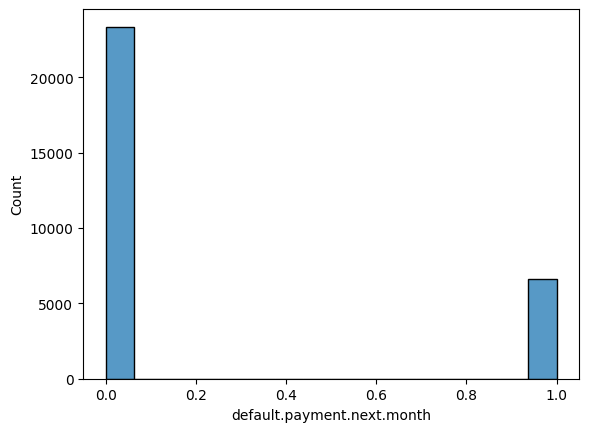

In [143]:
sns.histplot(y, bins = 'auto')

In [144]:
X_train, X_test, y_train, y_test = train_test_split(
                            X, y, test_size=0.2, random_state=42, stratify=y)

In [145]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score


model_cb = CatBoostClassifier(verbose = 0, random_state = 42)
model_cb.fit(X_train, y_train)

# y_pred = model_cb.predict(X_test)

y_pred_proba = model_cb.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_pred_proba)

print(f'roc auc score: {auc_test}')

roc auc score: 0.7771136631075503


Задача 2. Оценка важности признаков (2 балла)
- Встроенная важность CatBoost (PredictionValuesChange) используйте get_feature_importance() для получения важности признаков, основанной на изменении предсказаний.

- Permutation Importance,используйте sklearn.inspection.permutation_importance. Постройте боксплот важности признаков.

- SHAP-анализ, используйте SHAP-значения для тестовой выборки.Постройте summary plot (bar и dot). Выберите одно наблюдение и объясните его предсказание с помощью shap.force_plot

Важно! Вычисляйте важность на обучающей или валидационной выборке, но не на тестовой. Тестовая выборка используется только для финальной оценки модели.

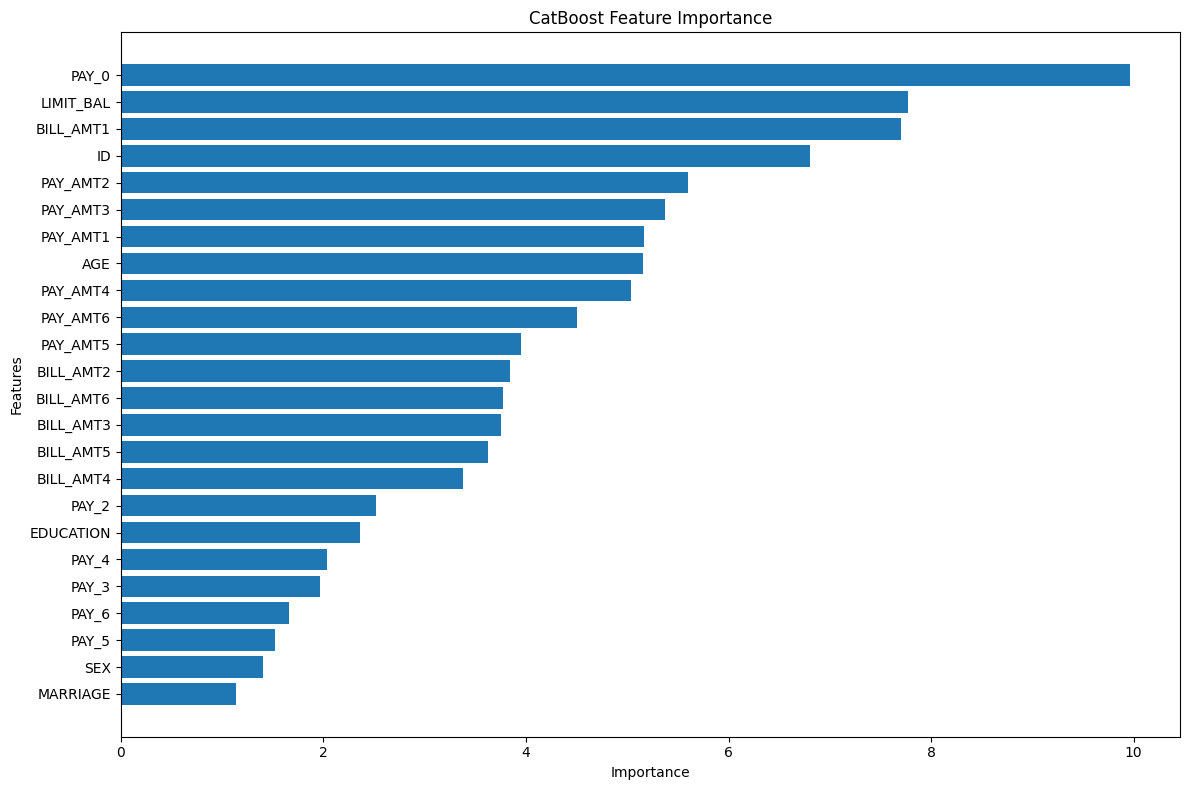

In [146]:
# Получаем массив значений важности
cat_importances = model_cb.get_feature_importance()
feature_importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': cat_importances})

feature_importance_df = feature_importance_df.sort_values('importance', ascending=True)

plt.figure(figsize=(12, 8))
plt.title("CatBoost Feature Importance")
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


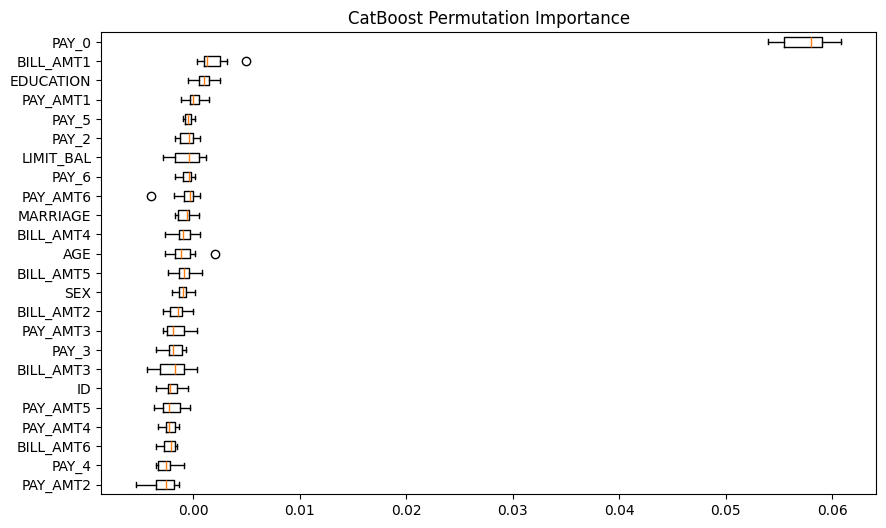

Признаки с отрицательным вкладом 
      feature  importance
19   PAY_AMT2   -0.002800
9       PAY_4   -0.002550
17  BILL_AMT6   -0.002300
21   PAY_AMT4   -0.002233
22   PAY_AMT5   -0.002083
0          ID   -0.002033
14  BILL_AMT3   -0.001917
8       PAY_3   -0.001817
20   PAY_AMT3   -0.001617
13  BILL_AMT2   -0.001533
2         SEX   -0.000983
16  BILL_AMT5   -0.000850
5         AGE   -0.000850
15  BILL_AMT4   -0.000850
4    MARRIAGE   -0.000733
23   PAY_AMT6   -0.000700
11      PAY_6   -0.000650
1   LIMIT_BAL   -0.000583
7       PAY_2   -0.000533
10      PAY_5   -0.000450


In [158]:
from sklearn.inspection import permutation_importance

cat_result = permutation_importance(
    model_cb
    ,X_test
    ,y_test
    ,n_repeats=10
    ,random_state=42
)

plt.figure(figsize=(10, 6))
plt.title("CatBoost Permutation Importance")
sorted_idx = cat_result.importances_mean.argsort()
plt.boxplot(
    cat_result.importances[sorted_idx].T,
    vert=False,
    tick_labels=X_test.columns[sorted_idx]
)

plt.show()

#отрицательная важность признаков
perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': cat_result.importances_mean
})

# Сортируем от меньшего к большему
perm_df = perm_df.sort_values('importance')

# Оставляем только те, у которых важность меньше 0
negative_features = perm_df[perm_df['importance'] < 0]

print("Признаки с отрицательным вкладом ")

print(negative_features)

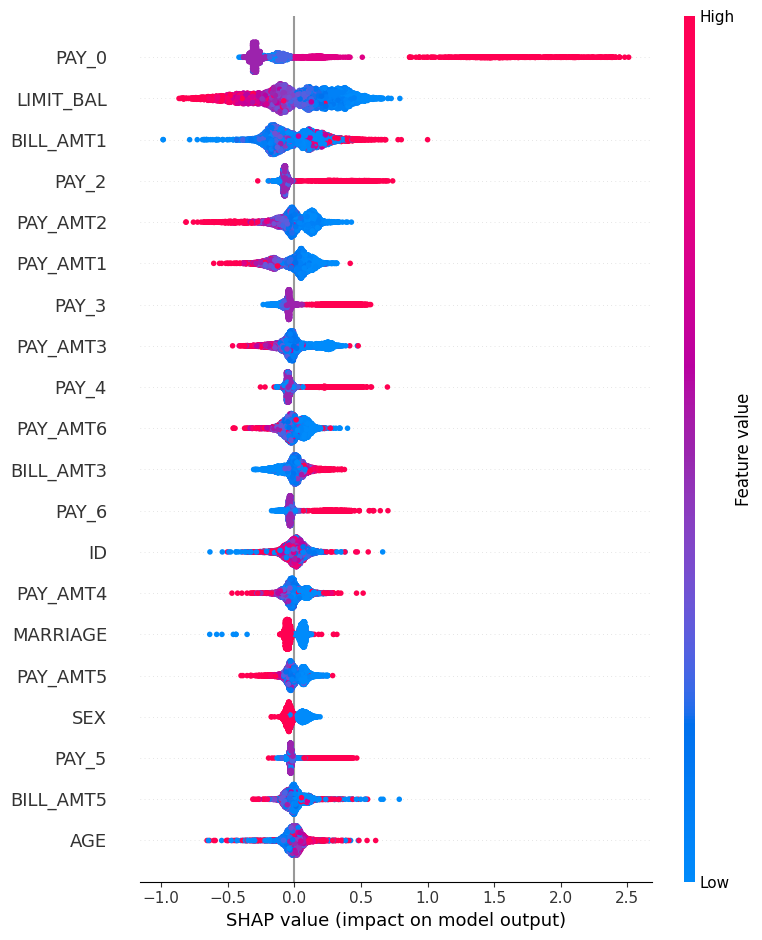

In [148]:
import shap
from catboost import Pool


my_pool = Pool(X_test, y_test)

cat_importances = model_cb.get_feature_importance(data=my_pool, type='ShapValues')

shap.summary_plot(
    cat_importances[:, :-1], # Убираем колонку (bias)
    X_test,
    plot_type="dot",
    feature_names=X_test.columns
)

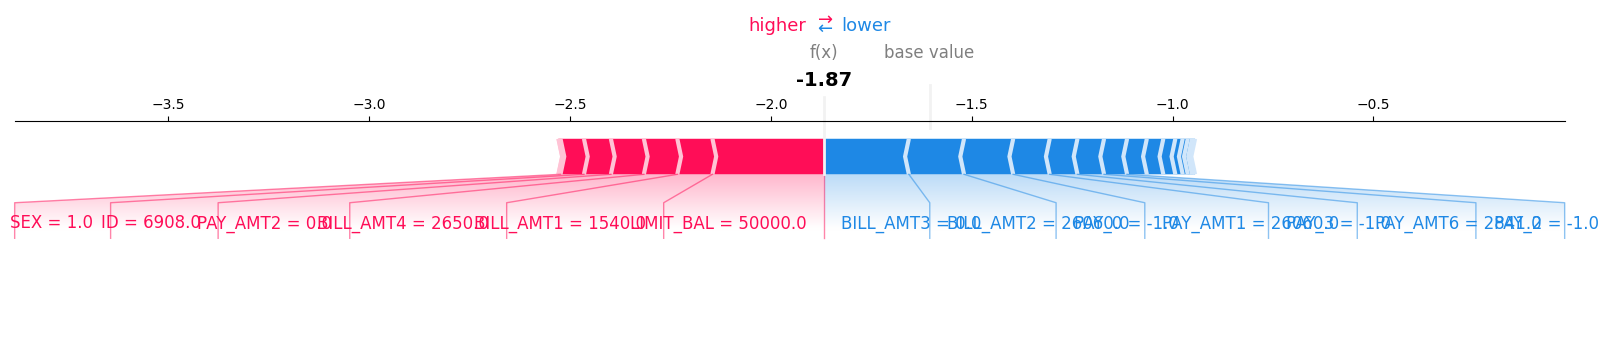

In [149]:
row_idx = 0

shap_values_one = cat_importances[row_idx, :-1]
base_value = cat_importances[row_idx, -1]

shap.force_plot(
    base_value,
    shap_values_one,
    X_test.iloc[row_idx],
    matplotlib=True
)

Задача 3. Выводы (1 балла)
- Сравните топ-5 важных признаков по каждому методу.

- Найдите признаки, которые важны во всех методах;важны только в одном методе; имеют отрицательную важность в Permutation Importance.

- Объясните, почему методы могут давать разные результаты.

Ответ:
- Для CatBoost топ признаков: PAY_0, LIMIT_BAL, BILL_AT1, ID, PAY_AMT2
- Для permutation_importance: PAY_0, BILL_AMT1, Education, PAY_AMT1, PAY_5
- Для shap: PAY_0, Limit_bal, BILL_AT1, PAY_2, PAY_AMT2
Попали во все: PAY_0, BILL_AT1
Только в одном методе: Education, PAY_AMT2, ID, PAY_5
Методы могут давать разные результаты, тк они реализованы по разному и смотрят на раные вещи, поэтому мало важные признаки могут входит в топ одного метода и не входить в топ другого
- Список с отрицательной важностью: PAY_AMT2, PAY_4, BILL_AMT6, PAY_AMT4, PAY_AMT5, ID, BILL_AMT3, PAY_3, PAY_AMT3, BILL_AMT2, SEX, BILL_AMT5, AGE, BILL_AMT4, MARRIAGE, PAY_AMT6, PAY_6, LIMIT_BAL, PAY_2, PAY_5




Задача 4. Отбор признаков (2 балла)

- Определите порог важности (например, важность случайного признака) и удалите менее важные признаки.

- Обучите модель на сокращённом наборе признаков и сравните ROC-AUC с исходной моделью.

- Можно ли сократить количество признаков без потери качества?

In [150]:

print(f"Исходный ROC-AUC (все признаки): {auc_test:.4f}")


# добавляю случайный признак
X_train_probe = X_train.copy()
X_train_probe['random_noise'] = np.random.uniform(0, 1, size=len(X_train))

# Обучаем probe-модель
model_probe = CatBoostClassifier(verbose=0, random_seed=42)
model_probe.fit(X_train_probe, y_train)

# Получаем важности
importances = model_probe.get_feature_importance()
feat_names = X_train_probe.columns

#ищем важность случайного признака
threshold = pd.DataFrame({'name': feat_names, 'imp': importances}) \
              .set_index('name').loc['random_noise', 'imp']

print(f"Порог отсечения (важность шума): {threshold:.4f}")



Исходный ROC-AUC (все признаки): 0.7771
Порог отсечения (важность шума): 6.1880


In [151]:
# оставим только те признаки, которые важнее случайного признака
mask = (importances > threshold)
selected_feats = np.array(feat_names)[mask]

selected_feats = [f for f in selected_feats if f != 'random_noise']

print(f"Отобрано признаков: {len(selected_feats)} из {len(X_train.columns)}")

Отобрано признаков: 4 из 24


In [152]:


model_selected = CatBoostClassifier(verbose=0, random_seed=42)
model_selected.fit(X_train[selected_feats], y_train)

# Предсказываем
y_pred_sel = model_selected.predict_proba(X_test[selected_feats])[:, 1]
auc_sel = roc_auc_score(y_test, y_pred_sel)

print(f"ROC-AUC после отбора: {auc_sel:.4f}")
print(f"Изменение качества: {auc_sel - auc_test:.4f}")


ROC-AUC после отбора: 0.7486
Изменение качества: -0.0285


Ответ: В данном случае не получилось отобрать признаки с сохранением или улучшением качеств

Задача 5. Анализ с добавленными случайными признаками (4 балла)

- Добавьте 10 случайных нормально распределенных признаков в датасет.

- Выполните оценку важности признаков (как в задаче 2) и проанализируйте, как методы ранжируют случайные признаки.

- Выполните отбор признаков с разными порогами 0%, 25%, 50%, 75% наименее важных признаков (удаляйте).

- Для каждого порога обучите модель и оцените ROC-AUC на тесте.

- Постройте график зависимости ROC-AUC от количества удаленных признаков.

- Проанализируйте, как изменяется качество модели при удалении разных долей признаков.


In [153]:
X_train_aug = X_train.copy()
X_test_aug = X_test.copy()

for i in range(10):
    col_name = f'random_feature_{i}'
    # генерируем шум (10 случайных признаков)
    X_train_aug[col_name] = np.random.normal(0, 1, size=len(X_train_aug))
    X_test_aug[col_name] = np.random.normal(0, 1, size=len(X_test_aug))

In [154]:
# Обучаем на данных с шумом
model_aug = CatBoostClassifier(verbose=0, random_seed=42)
model_aug.fit(X_train_aug, y_train)

# получаем важность
feature_importances = model_aug.get_feature_importance()
feat_df = pd.DataFrame({
    'feature': X_train_aug.columns,
    'importance': feature_importances
})

# сортируем
feat_df = feat_df.sort_values('importance', ascending=False).reset_index(drop=True)

In [155]:
print("\nПозиция случайных признаков")
# Находим позиции наших random_feature_X
random_rows = feat_df[feat_df['feature'].str.contains('random_feature')]
print(random_rows)

avg_rank = random_rows.index.values.mean()
print(f"\nСредняя позиция случайных признаков (индекс): {avg_rank:.1f} из {len(feat_df)}")


Позиция случайных признаков
             feature  importance
3   random_feature_9    4.196838
4   random_feature_8    4.115405
5   random_feature_2    3.904600
6   random_feature_6    3.789712
8   random_feature_3    3.695502
9   random_feature_7    3.552230
10  random_feature_4    3.539741
11  random_feature_1    3.410505
12  random_feature_0    3.340438
13  random_feature_5    3.312735

Средняя позиция случайных признаков (индекс): 8.1 из 34


In [156]:
# Отбор признаков с порогами 0%, 25%, 50%, 75%
drop_percentages = [0.0, 0.25, 0.50, 0.75]
results_auc = []
features_count = []


for pct in drop_percentages:
    n_total = len(feat_df)
    n_drop = int(n_total * pct)
    n_keep = n_total - n_drop

    # берем лучшие признаки
    top_features = feat_df['feature'].head(n_keep).tolist()

    # Обучаем только на лучших признаках
    model_tmp = CatBoostClassifier(verbose=0, random_seed=42)
    model_tmp.fit(X_train_aug[top_features], y_train)

    # предсказываем
    preds = model_tmp.predict_proba(X_test_aug[top_features])[:, 1]
    score = roc_auc_score(y_test, preds)

    results_auc.append(score)
    features_count.append(n_keep)

    print(f"Удалено {int(pct*100)}%  roc-auc: {score:.4f}")

Удалено 0%  roc-auc: 0.7742
Удалено 25%  roc-auc: 0.7689
Удалено 50%  roc-auc: 0.7576
Удалено 75%  roc-auc: 0.7463


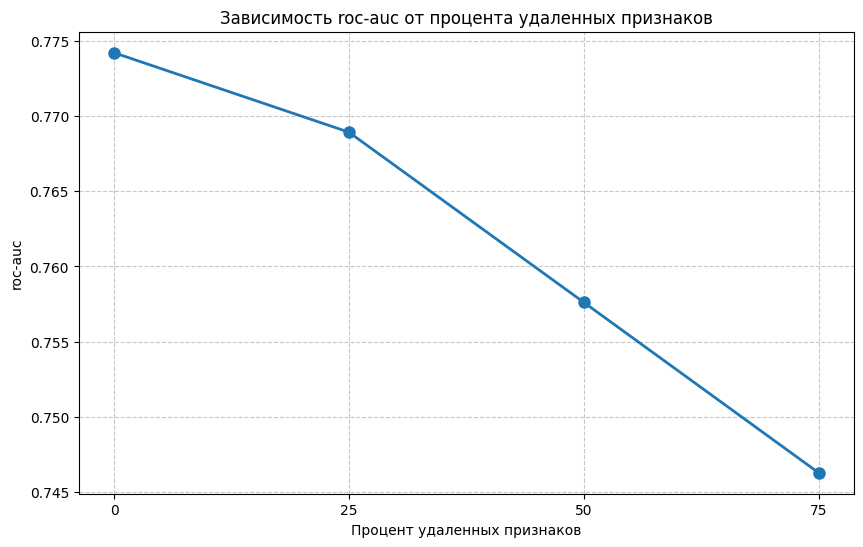

In [157]:
# Графики
plt.figure(figsize=(10, 6))
x_axis = [int(p*100) for p in drop_percentages]

plt.plot(x_axis, results_auc, marker='o', linewidth=2, markersize=8)
plt.title('Зависимость roc-auc от процента удаленных признаков')
plt.xlabel('Процент удаленных признаков')
plt.ylabel('roc-auc')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(x_axis)
plt.show()
